In [14]:
import pandas as pd
wine = pd.read_csv('https://bit.ly/wine_csv_data')
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [15]:
wine.info()
wine.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [17]:
data = wine[['alcohol', 'sugar','pH']].to_numpy()
target = wine['class'].to_numpy()

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

print(train_input.shape, test_input.shape)


(5197, 3) (1300, 3)


In [18]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))



0.7808350971714451
0.7776923076923077


In [19]:
print(lr.coef_, lr.intercept_)

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


## 결정 트리

In [20]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.996921300750433
0.8592307692307692


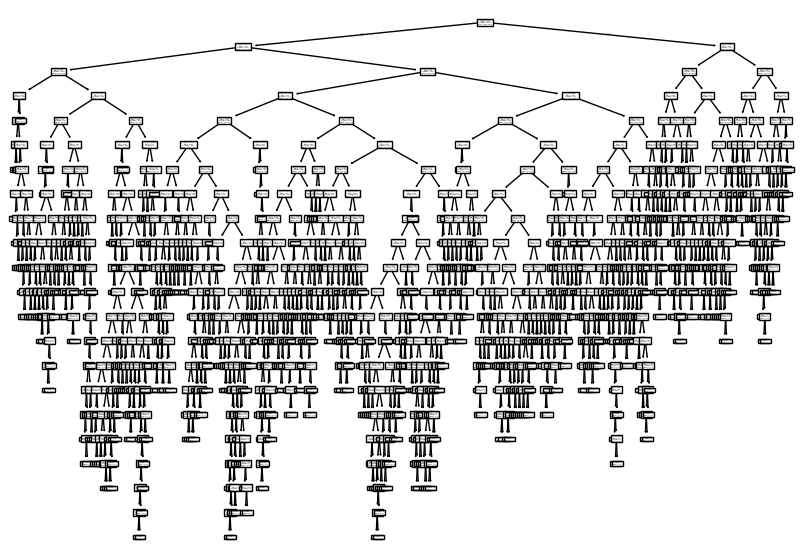

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10, 7))
plot_tree(dt)
plt.show()
# 맨위의 노드 : 루트 노드
# 맨 아래 노드 : 리프 노드

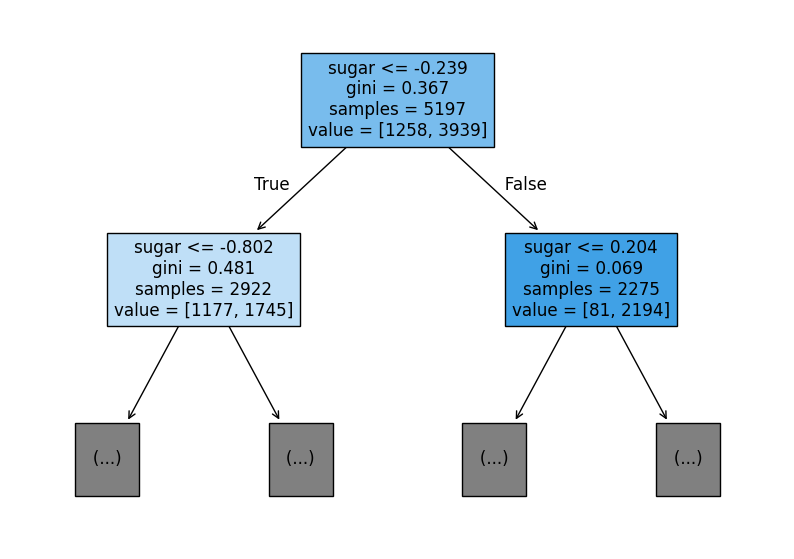

In [ ]:
plt.figure(figsize=(10,7))
plot_tree(dt, max_depth=1, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show() # max_depth 트리의 깊이 제한, filled=True : 클래스의 비율이 높아지면 색 진해짐

불순도(gini)
DecisionTreeClassifier 클래스의 criterion 매개변수의 기본값 :gini

지니 불순도 = 1- (음성 클래스 비율^2 + 양성 클래스 비율^2)

이부분 시간 날때 한 번 더 보기

## 가지치기

In [23]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.8454877814123533
0.8415384615384616


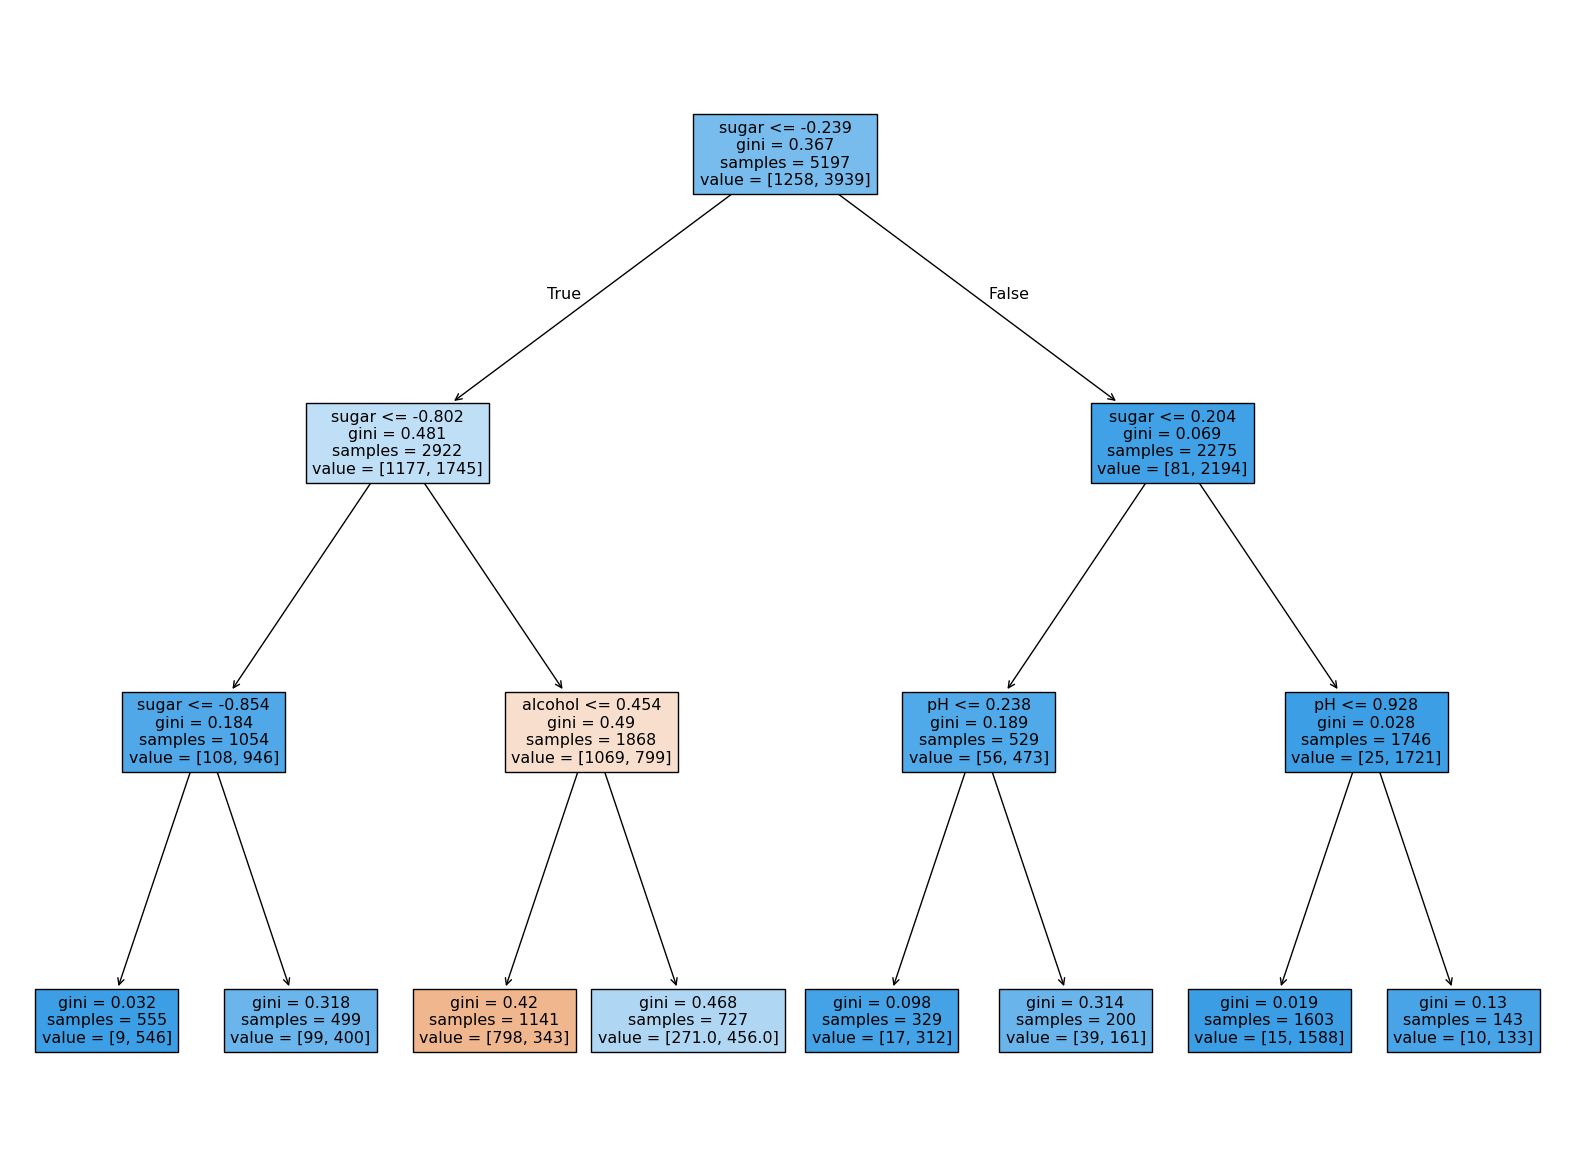

In [ ]:
plt.figure(figsize=(20,15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

In [ ]:
# 트리 알고리즘에 장점 : 특성값의 스케일이 계산에 영향을 미치지 않음, 따라서 표준화 전처리 필요 X
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

dt.fit(train_input, train_target)
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))

0.8454877814123533
0.8415384615384616
0.8454877814123533
0.8415384615384616


In [27]:
print(dt.feature_importances_)

[0.12345626 0.86862934 0.0079144 ]


## 검증 세트
- 테스트 세트를 사용하지 않고 훈련세트 나눠서 다른 테스트 세트 만들기

In [29]:
import pandas as pd
wine = pd.read_csv('https://bit.ly/wine_csv_data')

data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

In [30]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)
sub_input, val_input, sub_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)
print(sub_input.shape, val_input.shape)


(4157, 3) (1040, 3)


In [31]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(sub_input, sub_target)
print(dt.score(sub_input, sub_target))
print(dt.score(val_input, val_target))

0.9971133028626413
0.864423076923077


## 교차검증

In [ ]:
from sklearn.model_selection import cross_validate
scores = cross_validate(dt, train_input, train_target) 
# fit_time, score_time, test_score 키를 가진 딕셔너리 반환, 기본적으로 5-폴드
print(scores)

{'fit_time': array([0.00600171, 0.00507474, 0.00457168, 0.00487018, 0.0045743 ]), 'score_time': array([0.0013001 , 0.00064158, 0.00068688, 0.00084782, 0.00059438]), 'test_score': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}


In [ ]:
import numpy as np
print(np.mean(scores['test_score'])) # 검증 폴드의 점수

0.855300214703487


In [34]:
# 교차검증을 할때 훈련 세트를 섞으려면 분할기를 지정해야 함
# cross_validate() 기본적으로 KFold분할기 사용, 분류모델의 경우 StratifiedKfold 사용해야함
from sklearn.model_selection import StratifiedKFold
scores = cross_validate(dt, train_input, train_target, cv = StratifiedKFold())
print(np.mean(scores['test_score']))

0.855300214703487


In [35]:
# 훈련 세트를 섞은 후 10-폴드 교차검증 수행
splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(dt, train_input, train_target, cv=splitter)
print(np.mean(scores['test_score']))

0.8574181117533719


In [36]:
# GridSearchCV : 하이퍼파라미터 탐색과 교차 검증을 한 번에 수행
# cross_validate() 함수 호출 필요 없음
from sklearn.model_selection import GridSearchCV
params = {'min_impurity_decrease' : [0.0001, 0.0002, 0.0003, 0.0004, 0.0005]}
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)

gs.fit(train_input, train_target) # min_impurity_decrease 값을 바꿔가며 총 5회 실행
# GridSearchCV의 cv 기본값으 5 => 값마다 5-폴드 교차검증

# 교차 검증에서 최적의 하이퍼파라미터를 찾으면 전체 훈련 세트로 모델을 다시 만들어야함
# Gridsearch는 훈련이 끝나면 25개의 모델 중에서 검증 점수가 
# 가장 높은 모델의 매개변수 조합으로 전체 훈련 세트에서 자동으로 다시 모델을 훈련

dt = gs.best_estimator_ # 검증 점수가 가장 높은 모델이 저장되어 있음
print(dt.score(train_input, train_target))

0.9615162593804117


In [39]:
print(gs.best_params_)
print(gs.cv_results_['mean_test_score'])
best_index = np.argmax(gs.cv_results_['mean_test_score']) 
# np.argmax() 가장 큰 값의 인덱스를 추출
print(gs.cv_results_['params'][best_index])

{'min_impurity_decrease': 0.0001}
[0.86819297 0.86453617 0.86492226 0.86780891 0.86761605]
{'min_impurity_decrease': 0.0001}
